# Figure 2: Compute ocean heat uptake efficiency ($\kappa$) and plot with $\alpha$

Last updated Sept 29 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
# find files that start with a certain string
def find_files(directory,start_str):
    import os
    files = [f for f in os.listdir(directory) if f.startswith(start_str)]

    # Handle only the first matching file
    if files:
        matching_file = files[-1]
        #print(f"Found file: {matching_file}")
        return matching_file
    else:
        print(f"No file found {directory, start_str}.")
        return None

In [3]:
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = ['p6p0sol_CTL1860',
                'p4p0sol_CTL1860',
                'p2p0sol_CTL1860', 
                'p1p0sol_CTL1860',
                #'CTL1860_newdiag',
                'm1p0sol_CTL1860', 
                'm2p0sol_CTL1860',
                'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',]
        modelstr = 'FLOR'

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = ['CTL1860_p6pctSolar', 
                'CTL1860_p4pctSolar',
                'CTL1860_p2pctSolar',
                'CTL1860_p1pctSolar', 
                #'CTL1860',
                'CTL1860_m1pctSolar',
                'CTL1860_m2pctSolar',
                'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',
                ]
        modelstr = 'CM2.1'
    return exps, extension, modelstr

# Compute OHC and Ts anomaly from CTRL rolling climatology (50yr window, updated every 5 yrs)

In [4]:
def anomaly_from_moving_climatology(da, CTRL, window=50*12, step=5*12):
    
    anoms = []
    
    # Loop through the data in step-sized chunks
    for start in range(0, da.sizes['time'], step):
        end = start + step
        da_chunk = da.isel(time=slice(start, end))
        
        # Define corresponding climatology window in CTRL
        # (shift the window so it's aligned in time with da_chunk)
        t0 = da_chunk.time.values[0]
        
        # Find index in CTRL closest to t0
        idx0 = int(np.argmin(np.abs(CTRL.time.values - t0)))
        
        # Take 50-year slice of CTRL centered around idx0
        c_start = max(0, idx0 - window//2)
        c_end = min(CTRL.sizes['time'], c_start + window)
        CTRL_subset = CTRL.isel(time=slice(c_start, c_end))
        
        # Compute monthly climatology
        CTRL_clim = CTRL_subset.groupby("time.month").mean("time")
        
        # Compute anomaly for this chunk
        anom_chunk = da_chunk.groupby("time.month") - CTRL_clim
        anoms.append(anom_chunk)
    
    # Concatenate back together
    anom = xr.concat(anoms, dim="time")
    return anom


# Compute OHC and Ts anomalies from CTRL

In [5]:
def compute_OHU_Ts_anomaly(model, experiment, 
                 dirin_ohc = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/total_ocean_heat/',
                 dirin_Ts = '/tigress/mvchung/ANALYSIS/Solar_NEW/global_mean/'):

    # import monthly global total ocean heat content [J * 1e25]
    file = find_files(dirin_ohc,f'total_ocean_heat_ts_{model}_{experiment}')
    print(file)
    ohc = xr.open_dataarray(f'{dirin_ohc}{file}')
    ohc = ohc.squeeze()
    ohc = ohc*1e25 # convert to joules because model output was divided by 1e25
    
    # load CTRL ohc data
    if model == 'FLOR':
        CTRL_string = 'CTL1860_newdiag'
    elif model == 'CM2.1p1':
        CTRL_string = 'CTL1860'
    file = find_files(dirin_ohc,f'total_ocean_heat_ts_{model}_{CTRL_string}.')
    print(file)
    ohc_CTRL = xr.open_dataarray(f'{dirin_ohc}{file}')
    ohc_CTRL = ohc_CTRL.squeeze()
    ohc_CTRL = ohc_CTRL*1e25

    # compute ocean heat uptake anomaly from climatology
    earth_area = 4 * np.pi * (6.371e6)**2   # m²
    dt = (ohc.time.diff('time') / np.timedelta64(1, 's')) # time step difference [seconds]
    
    ohu = ohc.diff('time') / dt / earth_area      # ocean heat uptake [W/m2]
    ohu_CTRL = ohc_CTRL.diff('time') / dt / earth_area     # ocean heat uptake (CTRL) [W/m2]
    
    # get anomaly from 50-year moving climatology updated every 5 years
    ohu_anom = anomaly_from_moving_climatology(ohu, ohu_CTRL, window=50*12, step=5*12) # get anomaly
    ohu_anom_annual = ohu_anom.groupby('time.year').mean('time')  # annual mean
    
    # import surface temperature (Ts) data
    file = find_files(dirin_Ts,f't_ref_{model}_{experiment}_{extension}')
    Ts = xr.open_dataarray(f'{dirin_Ts}{file}')
    
    # import CTRL
    file = find_files(dirin_Ts,f't_ref_{model}_{CTRL_string}_{extension}')
    Ts_CTRL = xr.open_dataarray(f'{dirin_Ts}{file}')
    # get anomaly from CTRL
    Ts = anomaly_from_moving_climatology(Ts, Ts_CTRL, window=50*12, step=5*12) # get anomaly
    # get annual average
    Ts_annual = Ts.groupby('time.year').mean('time')

    # save data
    dirout = './processed_data/for_OHUE'
    ohu_anom_annual.to_netcdf(f'{dirout}/OHU_annual_anom_50yr_{model}_{experiment}.nc')
    Ts_annual.to_netcdf(f'{dirout}/t_ref_annual_anom_50yr_{model}_{experiment}.nc')
    
    return ohu_anom_annual, Ts_annual

In [8]:
# compute OHC and Ts anomalies from CTRL
# takes a few minutes

modelnames = ['CM2.1p1','FLOR']
modelstr = ['CM2.1','FLOR']

for ii in range(np.size(modelnames)):

    all_kappas = []  # store DataArrays
    
    # get the names of the experiments
    exps, extension, modelstr = get_experiment_names(modelnames[ii])

    for iexp in range(np.size(exps)):
        ohu_anom, Ts_annual = compute_OHU_Ts_anomaly(modelnames[ii], exps[iexp])
        

total_ocean_heat_ts_CM2.1p1_CTL1860_p6pctSolar.0101-0310.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_p4pctSolar.0101-2000.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_p2pctSolar.0101-1100.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_p1pctSolar.0101-0300.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_m1pctSolar.0101-0300.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_m2pctSolar.0101-1100.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_m4pctSolar.0101-2000.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_CM2.1p1_CTL1860_m6pctSolar.0101-1293.nc
total_ocean_heat_ts_CM2.1p1_CTL1860.0101-2200.nc
total_ocean_heat_ts_FLOR_p6p0sol_CTL1860.0101-1000.nc
total_ocean_heat_ts_FLOR_CTL1860_newdiag.0101-2200.nc
total_ocean_heat_ts_

Text(0, 0.5, '$\\kappa$ = OHU anom / T anom')

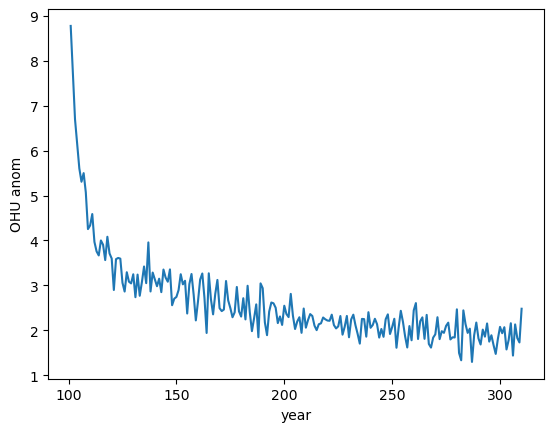

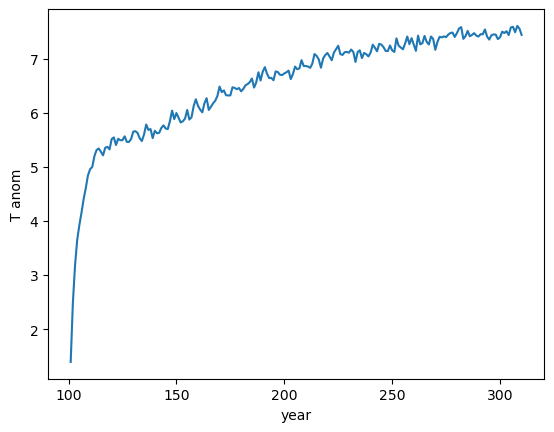

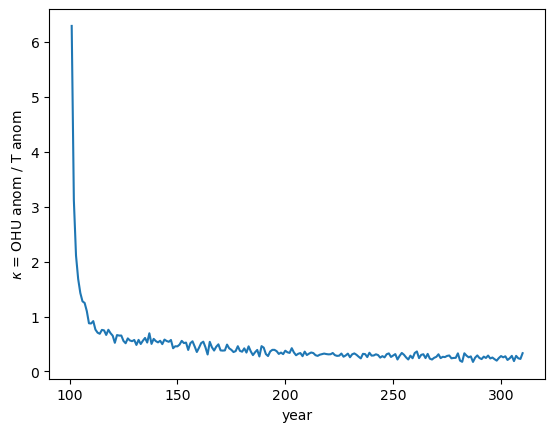

In [7]:
# plot to make sure it worked
N_anom = xr.open_dataarray('./processed_data/for_OHUE/OHU_annual_anom_50yr_CM2.1p1_CTL1860_p6pctSolar.nc')
Ts_anom = xr.open_dataarray('./processed_data/for_OHUE/t_ref_annual_anom_50yr_CM2.1p1_CTL1860_p6pctSolar.nc')

plt.figure()
N_anom.plot()
plt.ylabel('OHU anom')
plt.figure()
Ts_anom.plot()
plt.ylabel('T anom')

plt.figure()
(N_anom / Ts_anom).plot()
plt.ylabel('$\kappa$ = OHU anom / T anom')

# compute OHU efficiency $\kappa$

In [8]:
def compute_kappa_delta(model, experiment, label, window_len = 150,
                 dirin_ohc = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/for_OHUE/',
                 dirin_Ts = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/for_OHUE/'):
    # compute ocean heat uptake efficiency kappa = dOHU / dT

    # import annual ocean heat uptake anomaly [W/m2]
    file = find_files(dirin_ohc,f'OHU_annual_anom_50yr_{model}_{experiment}.nc')
    ohu_annual = xr.open_dataarray(f'{dirin_ohc}{file}')
    ohu_annual = ohu_annual.squeeze() 
    
    # import surface temperature (Ts) data
    file = find_files(dirin_Ts,f't_ref_annual_anom_50yr_{model}_{experiment}.nc')
    Ts_annual = xr.open_dataarray(f'{dirin_Ts}{file}')
    
    # compute OHU efficiency
    years_array = ohu_annual['year'].values # change
    
    kappa_da = ohu_annual / Ts_annual
    
    # Store in xarray
    kappa = xr.DataArray(
        kappa_da,
        coords={'year': ohu_annual['year'].values},
        dims='year',
        name=f'OHUeff_{label}',
        attrs={
            'units': 'W m$^{-2}$ K$^{-1}$',  # W per m² per Kelvin
            'long_name': 'OHU Efficiency'
        }
    )

    return kappa

# Compute and plot kappa for all the models and experiments

In [9]:
# load and plot all the experiments

plt.style.use('../func/paper.mplstyle')

modelnames = ['FLOR','CM2.1p1']
modelstr = ['FLOR','CM2.1']

labels = [
          '+6%',
          '+4%',
          '+2%',
          '+1%',
          #'CTRL',
          '-1%',
          '-2%',
          '-4%',
          '-6%',
        ]
colors = [
         'darkred',
         'red',
         'orange',
         'gold',
        #'grey',
         'cyan',
         'dodgerblue',
         'blue',
         'darkblue',
        ]

In [10]:
# compute OHU efficiency for all the experiments and models 
# takes a few minutes (computing anomalies from CTRL, could do this separately)

for ii in range(np.size(modelnames)):

    all_kappas = []  # store DataArrays
    
    # get the names of the experiments
    exps, extension, modelstr = get_experiment_names(modelnames[ii])

    for iexp in range(np.size(exps)):
        kappa = compute_kappa_delta(modelnames[ii], exps[iexp], label=labels[iexp], window_len=150)
        
        all_kappas.append(kappa)

    if modelnames[ii]=='FLOR':
        # Combine into one Dataset
        kappa_ds_FLOR = xr.merge(all_kappas) 
    else:
        kappa_ds_CM21 = xr.merge(all_kappas) 

Text(0.5, 0.98, 'OHU efficiency ($\\kappa$)')

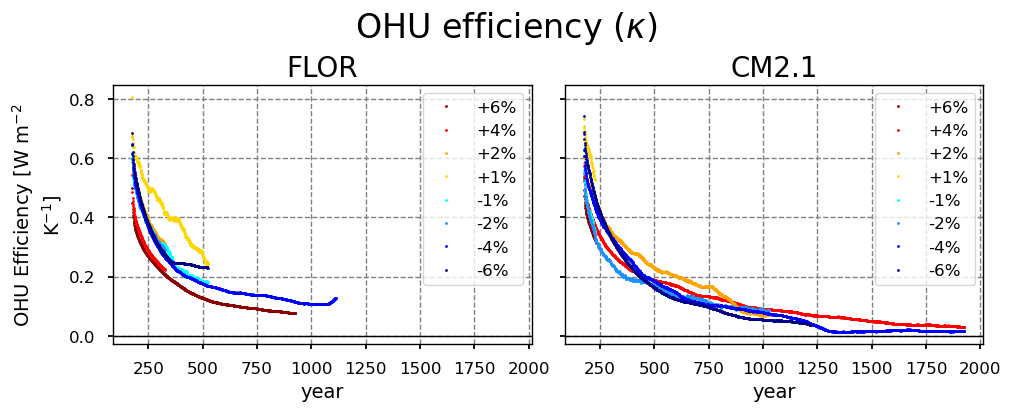

In [13]:
# plot

# rolling average [years]
window = 150 # sliding window used to compute radiative feedbacks

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

# Left panel = FLOR variables
for ivar, var_name in enumerate(kappa_ds_FLOR.data_vars):
    kappa_ds_FLOR[var_name].rolling(year=window,center=True).mean('year').plot(
        ax=ax[0],
        color=colors[ivar],
        label=labels[ivar],
        zorder=1,
        linestyle='None',
        marker='.',
        markersize=2)

# Right panel = CM2.1 variables
for ivar, var_name in enumerate(kappa_ds_CM21.data_vars):
    kappa_ds_CM21[var_name].rolling(year=window,center=True).mean('year').plot(
        ax=ax[1],
        color=colors[ivar],
        label=labels[ivar],
        zorder=1,
        linestyle='None',
        marker='.',
        markersize=2)

for axis in ax.flatten():
    axis.legend()
    axis.grid('--')
    axis.axhline(0, color='k', linewidth=1)

ax[0].set_title('FLOR')
ax[1].set_title('CM2.1')
ax[1].set_ylabel('')
#ax[0].set_ylim(-2,2)

fig.suptitle('OHU efficiency ($\kappa$)')


In [14]:
kappa_ds_FLOR

<xarray.Dataset> Size: 78kB
Dimensions:     (year: 1087)
Coordinates:
  * year        (year) int64 9kB 101 102 103 104 105 ... 1184 1185 1186 1187
Data variables:
    OHUeff_+6%  (year) float64 9kB 7.697 3.242 2.055 1.583 ... nan nan nan nan
    OHUeff_+4%  (year) float64 9kB 8.793 3.033 2.002 1.783 ... nan nan nan nan
    OHUeff_+2%  (year) float64 9kB 12.14 2.676 1.966 2.557 ... nan nan nan nan
    OHUeff_+1%  (year) float64 9kB 20.65 1.569 1.73 2.059 ... nan nan nan nan
    OHUeff_-1%  (year) float64 9kB 2.531 3.467 1.419 3.176 ... nan nan nan nan
    OHUeff_-2%  (year) float64 9kB 3.701 4.481 2.727 1.138 ... nan nan nan nan
    OHUeff_-4%  (year) float64 9kB 5.358 3.661 2.249 ... 0.2058 0.2169 0.2308
    OHUeff_-6%  (year) float64 9kB 6.203 3.793 2.387 1.991 ... nan nan nan nan
Attributes:
    units:      W m$^{-2}$ K$^{-1}$
    long_name:  OHU Efficiency

In [15]:
# plot to compare between models

diff = kappa_ds_FLOR.rolling(year=150,center=True).mean('year') - kappa_ds_CM21.rolling(year=150,center=True).mean('year')

Text(0, 0.5, 'w m^-2 K^-1')

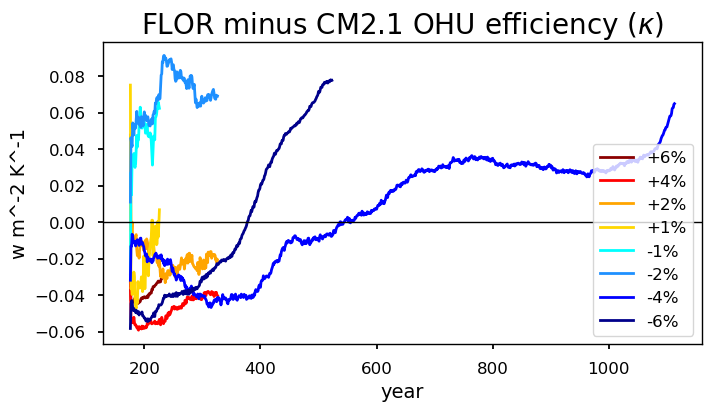

In [17]:
diff['OHUeff_+6%'].plot(color='darkred',label='+6%')
diff['OHUeff_+4%'].plot(color='r',label='+4%')
diff['OHUeff_+2%'].plot(color='orange',label='+2%')
diff['OHUeff_+1%'].plot(color='gold',label='+1%')
diff['OHUeff_-1%'].plot(color='cyan',label='-1%')
diff['OHUeff_-2%'].plot(color='dodgerblue',label='-2%')
diff['OHUeff_-4%'].plot(color='b',label='-4%')
diff['OHUeff_-6%'].plot(color='darkblue',label='-6%')

plt.title('FLOR minus CM2.1 OHU efficiency ($\kappa$)')
plt.axhline(0,color='k',linewidth=1)

plt.legend()
plt.ylabel('w m^-2 K^-1')

# Plot all together including the sum of $\alpha$ and $\kappa$

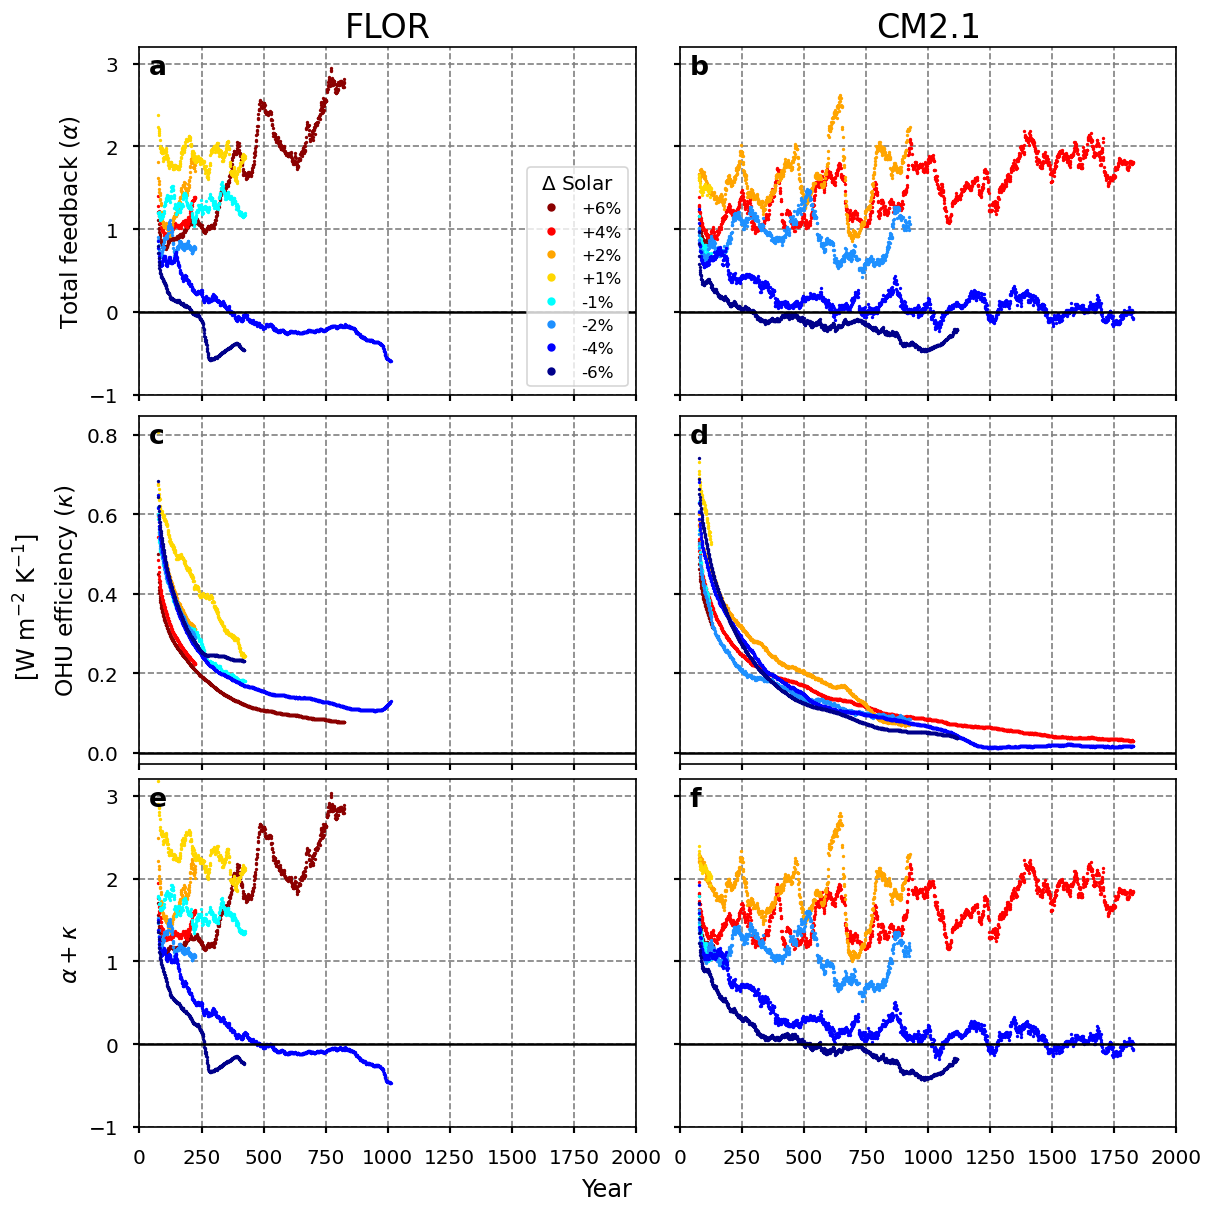

In [24]:
ref = '50yr'
window_size = 150

fig, ax = plt.subplots(3,2,figsize=(10,10), dpi=120, sharex=True, sharey='row')

models = ['FLOR','CM2.1p1']

for imodel in range(np.size(models)):

    for iexp in range(np.size(labels)):
    
        exps, extension, modelstr = get_experiment_names(models[imodel])
        exp = labels[iexp]

        #print(modelstr, exp)
        total_feedback = xr.open_dataarray(f'./feedbacks_MVC/total_feedback_cloud/total_feedback_{models[imodel]}_{exp}solar_ref_{ref}_window_150.nc')
        alpha = -total_feedback
        
        #total_feedback = xr.open_dataarray(f'./feedbacks_MVC/total_feedback_cloud_delta/total_feedback_{models[imodel]}_{exp}solar_ref_{ref}_window_30.nc')
        #alpha = -total_feedback#.rolling(year=window_size,center=True).mean('year')
        
        # plot total climate feedback -- constant rh decomposition
        # 150-year window, shifting reference period (50 years, every 5 years)        
        # centered on window (x-axis)
        
        ax[0,imodel].plot(alpha.year-101,
                          alpha, 
                          linestyle='None', marker = '.', markersize=2,
                      label=f'{exp}',
                        color=colors[iexp])
        ax[0,imodel].set_title(models[imodel])
        ax[0,imodel].set_ylim(-1,3.2)

        # plot OHU efficiency
        if models[imodel]=='FLOR':
            kappa = kappa_ds_FLOR.rolling(year=window_size,center=True).mean('year')
        else:
            kappa = kappa_ds_CM21.rolling(year=window_size,center=True).mean('year')
        ax[1,imodel].plot(kappa.year-101, 
                          kappa[f'OHUeff_{exp}'], 
                          linestyle='None', marker = '.', markersize=2,label=f'{exp}',
                        color=colors[iexp])
        #ax[1,imodel].set_ylim(-1,3.2)
        
        # plot lamba + kappa
        kappa_cleaned = kappa[f'OHUeff_{exp}'].where(~xr.ufuncs.isnan(kappa[f'OHUeff_{exp}']), drop=True)
        alpha_cleaned = alpha.where(~xr.ufuncs.isnan(alpha), drop=True)
        ax[2,imodel].plot(alpha_cleaned.year-101, 
                          kappa_cleaned + alpha_cleaned,
                          #kappa_cleaned + alpha_cleaned, 
                          linestyle='None', marker = '.', markersize=2,label=f'{exp}',
                        color=colors[iexp])
        ax[2,imodel].set_ylim(-1,3.2)
        

legend = ax[0,0].legend(title=r'$\Delta$ Solar',fontsize=10, markerscale=4,loc='lower right') # makes the legend markers bigger
    

for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.axhline(0,color='k',linewidth=1.5)
    axis.grid('--')
    axis.set_xlim(0,2000)


# Add subplot labels 'a', 'b', 'c', 'd' in upper left corners
subplot_labels = ['a', 'b', 'c', 'd', 'e', 'f']
for i, axis in enumerate(ax.flatten()):
    axis.text(0.02, 0.98, subplot_labels[i],
              transform=axis.transAxes,
              fontsize=16,
              fontweight='bold',
              va='top', ha='left')

ax[0,1].set_title('CM2.1')
fig.supxlabel('Year')
ax[0,0].set_ylabel(r'Total feedback ($\alpha$)')
ax[1,0].set_ylabel(r'OHU efficiency ($\kappa$)')
ax[2,0].set_ylabel(r'$\alpha + \kappa$')
fig.supylabel('[W m$^{-2}$ K$^{-1}$]')
#fig.suptitle(f'{window_size}-yr rolling average',fontsize=12)

plt.savefig('Figure2.pdf',dpi=300)